In [15]:
#!pip install xarray
#!pip install scipy
#!pip install cdsapi

#### Import Libraries

In [16]:
import xarray as xr
import numpy as np
import pandas as pd
import marineHeatWaves as mhw
import datetime as dt
import math

import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
from rasterio.transform import from_origin

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from matplotlib.gridspec import GridSpec

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

#### Define Slice Function

The coordinates have to be defined in 0-360 format.

In [17]:
def spatial_subset(ds):
    out = ds.sel(lon = slice(350.0, 355.0),
                 lat = slice(36.0, 42.3))
    return out

In [18]:

def build_shape_mask(ds, shapefile):
    """
    Build a boolean mask on the native OISST grid.
    Assumes ds.lon is in 0-360 format.
    """

    gdf = gpd.read_file(shapefile).to_crs("EPSG:4326")

    # ---- convert shapefile lon from -180..180 → 0..360 ----
    gdf["geometry"] = gdf.geometry.translate(xoff=360)
    gdf["geometry"] = gdf.geometry.buffer(0)

    # grid spacing
    dlat = float(abs(ds.lat[1] - ds.lat[0]))
    dlon = float(abs(ds.lon[1] - ds.lon[0]))

    # raster transform (cell-centered grid)
    transform = from_origin(
        ds.lon.min().item() - dlon / 2,
        ds.lat.max().item() + dlat / 2,
        dlon,
        dlat
    )

    mask = geometry_mask(
        gdf.geometry,
        out_shape=(ds.dims["lat"], ds.dims["lon"]),
        transform=transform,
        invert=True
    )

    # flip latitude to match xarray ordering
    mask = mask[::-1, :]

    return xr.DataArray(
        mask,
        coords={"lat": ds.lat, "lon": ds.lon},
        dims=("lat", "lon")
    )


In [19]:
ref_ds = xr.open_dataset("oisst_daily/sst.day.mean.1982.nc")
shape_mask = build_shape_mask(ref_ds, "201_400m/201_400m.shp")

/var/folders/wq/98_by44j0113pwx7jtjgd74w0000gn/T/ipykernel_1497/215378859.py:27: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_shape=(ds.dims["lat"], ds.dims["lon"]),


## Get Baseline

Baseline used is 1981-2010

In [20]:
baseline_df = pd.DataFrame()

for year in range(1982, 2012):

    var = xr.open_dataset(f"oisst_daily/sst.day.mean.{year}.nc", 
                        engine="netcdf4", decode_times=True)
    
    print(f'Opening {year}')
    
    var_sel = spatial_subset(var).where(shape_mask)
    
    var_sst = var_sel["sst"]

    baseline_df = pd.concat([baseline_df, var_sst.to_dataframe()])
    
del var

Opening 1982
Opening 1983
Opening 1984
Opening 1985
Opening 1986
Opening 1987
Opening 1988
Opening 1989
Opening 1990
Opening 1991
Opening 1992
Opening 1993
Opening 1994
Opening 1995
Opening 1996
Opening 1997
Opening 1998
Opening 1999
Opening 2000
Opening 2001
Opening 2002
Opening 2003
Opening 2004
Opening 2005
Opening 2006
Opening 2007
Opening 2008
Opening 2009
Opening 2010
Opening 2011


## Years to Analyse

In [31]:

y2023 = xr.open_dataset("oisst_daily/sst.day.mean.2023.nc", 
                        engine="netcdf4", decode_times=True)

#### Slice datasets' coordinates

In [32]:
y2023_sel = spatial_subset(y2023).where(shape_mask)
y2023_sst = y2023_sel["sst"]
y2023_time = y2023_sel["time"]

In [33]:
baseline_df = baseline_df.reset_index()
y2023_df = y2023_sst.to_dataframe().reset_index()

## Conversion to ordinal time

In [34]:
def to_ordinal(time_array):
    ordinals = []

    for t in time_array:
        # Case 1: numpy.datetime64
        if isinstance(t, np.datetime64):
            ts = pd.Timestamp(t)
            ordinals.append(ts.to_pydatetime().date().toordinal())

        # Case 2: cftime objects
        else:
            ordinals.append(dt.date(t.year, t.month, t.day).toordinal())

    return np.array(ordinals)

## Detect MHWs

In [35]:
def detect_mhw_year(year_df, baseline_df, climatology_period=(1982, 2011)):
    results = []

    for (lat, lon), group_year in year_df.groupby(["lat", "lon"]):

        # --- year data ---
        y_sst = group_year["sst"].values
        y_time = group_year["time"].values
        y_time_ord = to_ordinal(y_time)

        # --- baseline for same grid cell ---
        base_group = baseline_df[
            (baseline_df["lat"] == lat) &
            (baseline_df["lon"] == lon)
        ]

        if base_group.empty:
            continue

        base_sst = base_group["sst"].values
        base_time = base_group["time"].values
        base_time_ord = to_ordinal(base_time)

        base_years = pd.to_datetime(base_time).year

        if (base_years.min() > climatology_period[0] or
            base_years.max() < climatology_period[1]):
            continue

        # --- MHW detection ---
        mhw_ev, clim = mhw.detect(
            y_time_ord,
            y_sst,
            climatologyPeriod= list(climatology_period),
            alternateClimatology= [base_time_ord, base_sst]
        )

        results.append({
            "year": pd.to_datetime(y_time[0]).year,
            "lat": lat,
            "lon": lon,
            "n_events": mhw_ev["n_events"],
            "total_duration": (
                np.sum(mhw_ev["duration"])
            ),
            "max_intensity": (
                np.max(mhw_ev["intensity_max"])
                if mhw_ev["n_events"] > 0 else np.nan
            ),
            "mean_intensity":
                float(np.mean(mhw_ev["intensity_mean"]))

        })

    return pd.DataFrame(results)


In [36]:

df_2023 = detect_mhw_year(y2023_df, baseline_df)

yearly_dfs = {
    2023: df_2023
}

## Graphs

#### By number of events

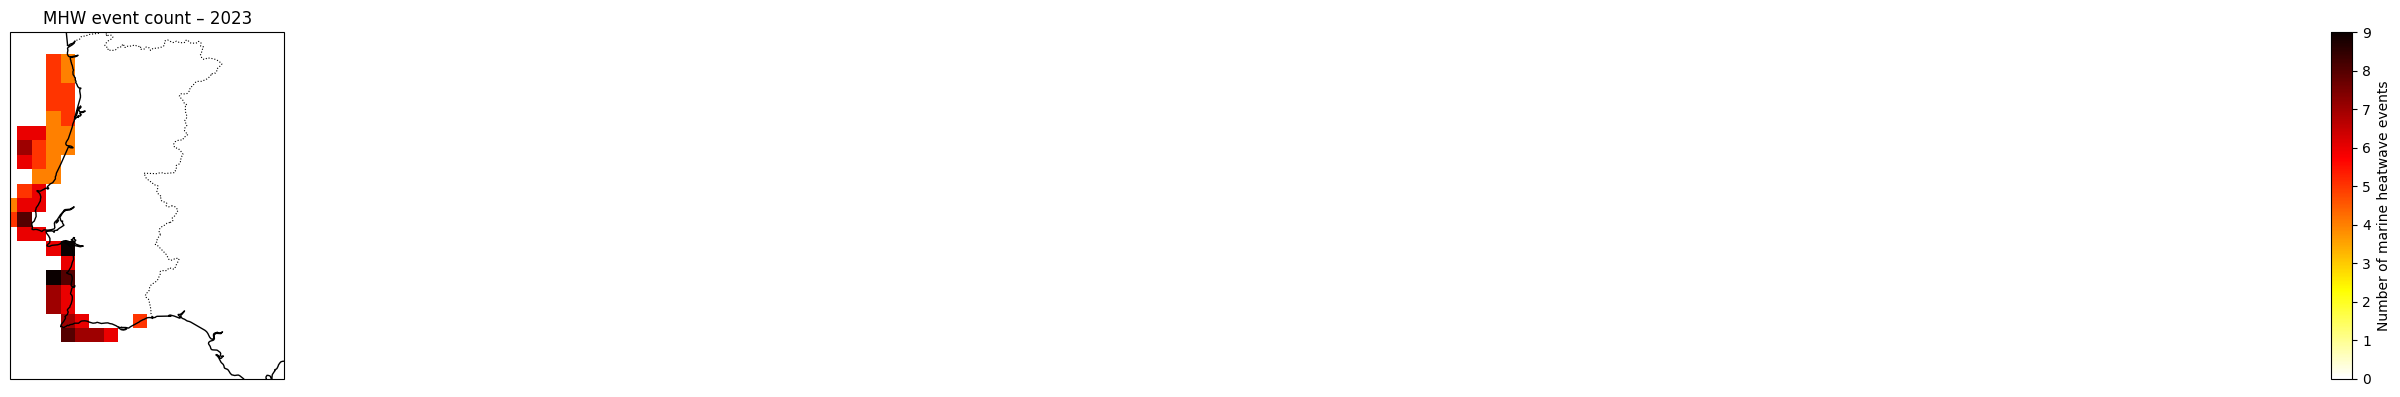

In [38]:
# =================================================
# OCEAN MASK (native grid)
# =================================================

ds_mask = y2023_sel

ocean_mask = ~np.isnan(ds_mask["sst"].isel(time=0))

lon = ds_mask["lon"].values
lat = ds_mask["lat"].values
lon2d, lat2d = np.meshgrid(lon, lat)


# =================================================
# FIGURE LAYOUT (SCALABLE)
# =================================================

n_panels = len(yearly_dfs)
ncols = 5
nrows = math.ceil(n_panels / ncols)

fig = plt.figure(figsize=(6 * ncols + 1.2, 4.5 * nrows))

gs = GridSpec(
    nrows,
    ncols + 1,
    width_ratios=[1] * ncols + [0.05],
    wspace=0.15,
    hspace=0.15
)

axes = []
for i in range(n_panels):
    r = i // ncols
    c = i % ncols
    ax = fig.add_subplot(gs[r, c], projection=ccrs.PlateCarree())
    axes.append(ax)

cax = fig.add_subplot(gs[:, -1])


# =================================================
# SHARED COLOR SCALE (EVENT COUNTS)
# =================================================

vmin = 0
vmax = max(df["n_events"].max() for df in yearly_dfs.values())


# =================================================
# PLOT EACH YEAR — NO INTERPOLATION
# =================================================

for ax, (year, df) in zip(axes, yearly_dfs.items()):

    # ---------------------------------------------
    # Map event counts to native grid
    # ---------------------------------------------
    grid = (
        df
        .pivot(index="lat", columns="lon", values="n_events")
        .reindex(index=lat, columns=lon)
        .values
    )

    # Apply land mask
    grid = np.ma.masked_where(~ocean_mask.values, grid)

    # ---------------------------------------------
    # Plot
    # ---------------------------------------------
    mesh = ax.pcolormesh(
        lon2d,
        lat2d,
        grid,
        cmap="hot_r",
        shading="nearest",   # 👈 NO interpolation
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.set_extent(
        [lon.min(), lon.max(), lat.min(), lat.max()],
        crs=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)

    ax.set_title(f"MHW event count – {year}")


# =================================================
# SHARED COLORBAR
# =================================================

cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("Number of marine heatwave events")

plt.show()


#### By total duration

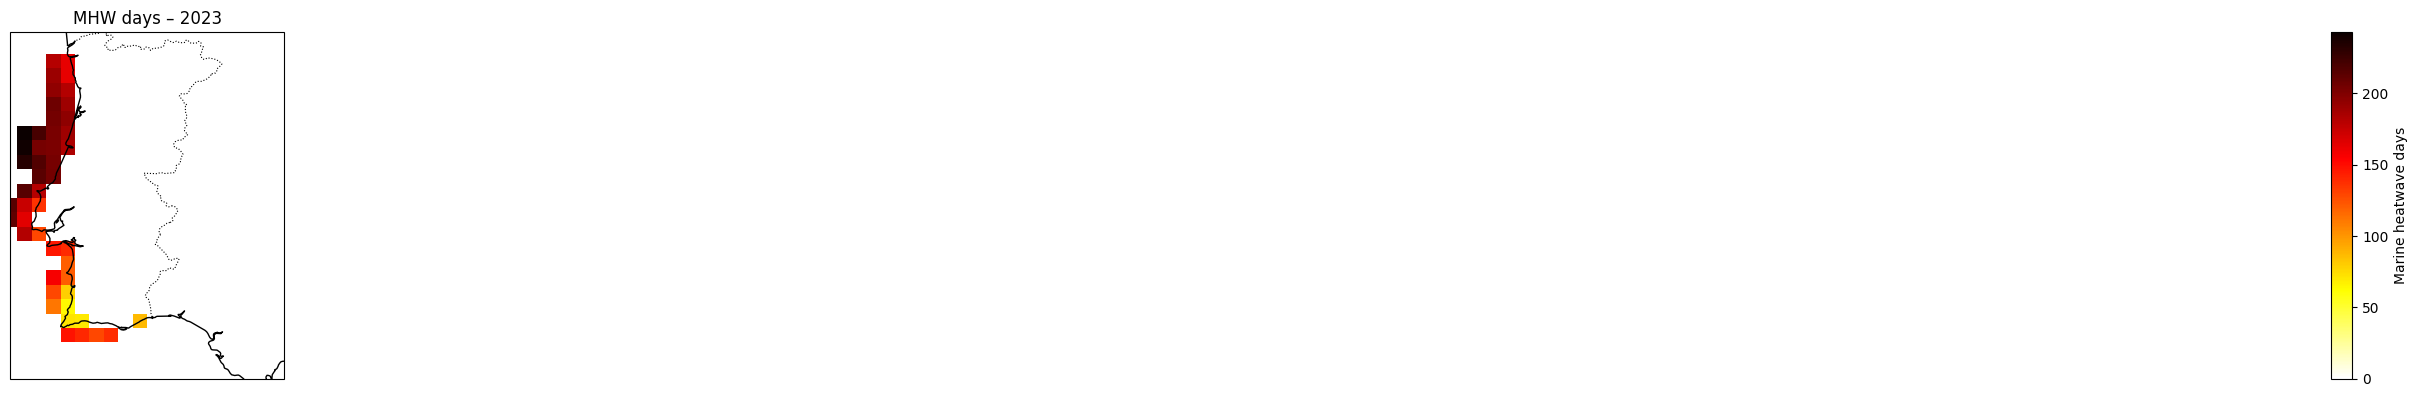

In [39]:
# =================================================
# OCEAN MASK (native grid)
# =================================================

ds_mask = ds_mask  # already y2022_sel or similar

ocean_mask = ~np.isnan(ds_mask["sst"].isel(time=0))

lon = ds_mask["lon"].values
lat = ds_mask["lat"].values

lon2d, lat2d = np.meshgrid(lon, lat)


# =================================================
# FIGURE LAYOUT (SCALABLE)
# =================================================

n_panels = len(yearly_dfs)
ncols = 5
nrows = math.ceil(n_panels / ncols)

fig = plt.figure(figsize=(6 * ncols + 1.2, 4.5 * nrows))

gs = GridSpec(
    nrows,
    ncols + 1,
    width_ratios=[1] * ncols + [0.05],
    wspace=0.15,
    hspace=0.15
)

axes = []
for i in range(n_panels):
    r = i // ncols
    c = i % ncols
    ax = fig.add_subplot(gs[r, c], projection=ccrs.PlateCarree())
    axes.append(ax)

cax = fig.add_subplot(gs[:, -1])


# =================================================
# SHARED COLOR SCALE
# =================================================

vmin = 0
vmax = max(df["total_duration"].max() for df in yearly_dfs.values())


# =================================================
# PLOT EACH YEAR — NO INTERPOLATION
# =================================================

for ax, (year, df) in zip(axes, yearly_dfs.items()):

    # ---------------------------------------------
    # Put values on native grid
    # ---------------------------------------------
    grid = (
        df
        .pivot(index="lat", columns="lon", values="total_duration")
        .reindex(index=lat, columns=lon)
        .values
    )

    # Apply land mask
    grid = np.ma.masked_where(~ocean_mask.values, grid)

    # ---------------------------------------------
    # Plot
    # ---------------------------------------------
    mesh = ax.pcolormesh(
        lon2d,
        lat2d,
        grid,
        cmap="hot_r",
        shading="nearest",   
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.set_extent(
        [lon.min(), lon.max(), lat.min(), lat.max()],
        crs=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)

    ax.set_title(f"MHW days – {year}")


# =================================================
# SHARED COLORBAR
# =================================================

cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("Marine heatwave days")

plt.show()